---
short_title: 'Notebook 00 · Audio Foundation'
downloads:
  - url: https://colab.research.google.com/github/Souvik-Mandal-Harvard/Computational-Behavioral-Sciences_LS100_Harvard/blob/main/LS100_01B_Audio-Data/LS100_Audio-data_00_Foundation_LastUpdated-20260609.ipynb
    title: Open in Colab
  - url: https://codespaces.new/Souvik-Mandal-Harvard/Computational-Behavioral-Sciences_LS100_Harvard?devcontainer_path=.devcontainer%2Fdevcontainer.json
    title: Open in GitHub Codespaces
  - file: LS100_Audio-data_00_Foundation_LastUpdated-20260609.ipynb
    title: Download notebook
---


# Understanding & Exploring Digital Audio as Data

*Authored by* **Souvik Mandal, Ph.D.**

*Project Leader & Instructor, Computational Behavioral Sciences, LS100, FAS, Harvard University* | Linkedin ID: [souvik-mandal-phd](https://www.linkedin.com/in/souvik-mandal-phd/)

---

_Last updated: 2026-07-02_ <!--last-updated-->


This notebook is the hands-on lab corresponding to the LS100 Guide **"Sound as Digital Data"**.

In this notebook, you'll:
1. Learn how audio data is digitally represented.
1. Load an audio file and inspect basic properties (sample rate, duration).
1. Visualize the waveform.
1. Record audio from your microphone (short clip).
1. Compute and visualize a **spectrogram** of an audio file.

> Requirements: `librosa`, `sounddevice`, `soundfile`, and `matplotlib`  
> Install as needed: `%pip install librosa sounddevice soundfile matplotlib`


In [3]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import librosa, librosa.display
import sounddevice as sd
import soundfile as sf

from IPython.display import Audio

In [4]:
# Configure plotting aesthetics for clear data visualization
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.style.use('default')
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['figure.dpi'] = 100

### Creating Digital Audio from Numbers

#### 1.A. Createing One-tone Audio

Let's start with creating a simple digital audio file. For that, we have to define a few parameters first.
1. The sampling rate
2. The length of the file in seconds
3. The frequency of the sound
4. The amplitude of the sound

In [5]:
# --- DSP Parameters ---
sampling_rate = 44100  # f_s: Temporal discretization rate (Hz)
duration = 2.0         # Total signal duration in seconds
frequency = 200.0      # Target fundamental pitch (Hz) - Concert A4
amplitude = 0.9      # Peak scalar amplitude (normalized volume range: 0.0 to 1.0)

# 1. Generate a discrete 1D time array from 0 to 'duration'
# Total samples = sampling_rate * duration
total_samples = int(sampling_rate * duration)
time_array = np.linspace(0, duration, total_samples, endpoint=False)

# 2. Synthesize the composite wave function: y = A * sin(2 * pi * f * t)
audio_signal = amplitude * np.sin(2 * np.pi * frequency * time_array)
print(audio_signal)

# Render the interactive HTML5 audio playback widget
Audio(audio_signal, rate=sampling_rate, normalize=False) # Set normalize=False to preserve original amplitude levels

[ 0.          0.02564218  0.05126355 ... -0.07684329 -0.05126355
 -0.02564218]


The produced file `audio_signal` is not a specialized multimedia format; it is a standard, flat float64 array of raw numbers, corresponding to the amplitudes of the sound and stored thosevalues in a numpy array.

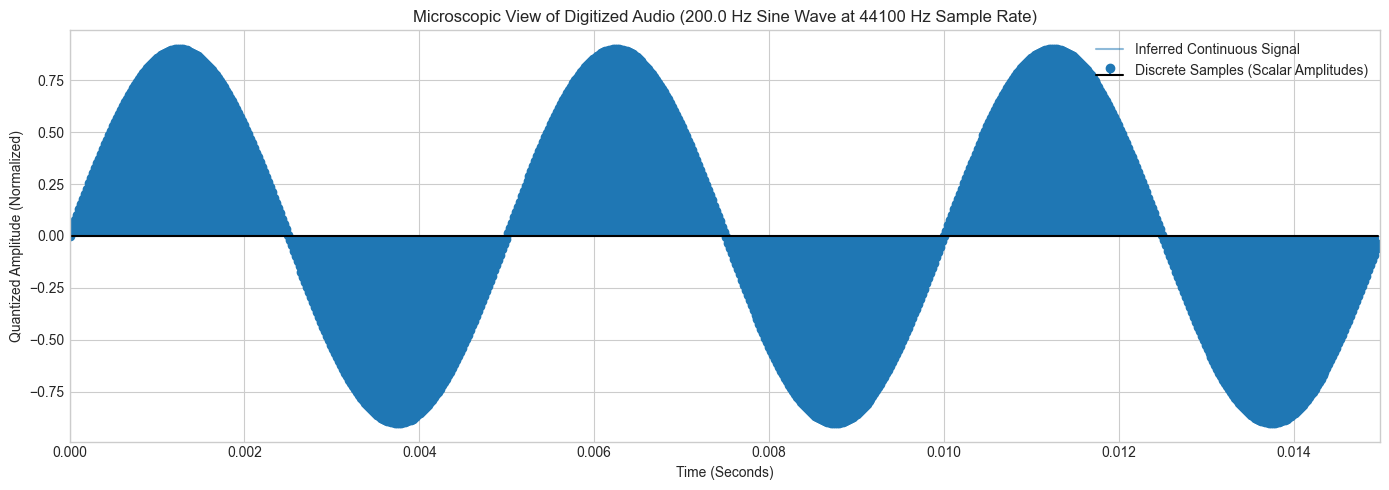

In [6]:
# Define a micro-window to display roughly 3 complete cycles
# At 440 Hz, one cycle takes ~0.00227 seconds
zoom_samples = int(sampling_rate * (3 / frequency))

plt.figure(figsize=(14, 5))

# Plot the underlying inferred continuous wave function
plt.plot(time_array[:zoom_samples], audio_signal[:zoom_samples], 
         color='#1f77b4', alpha=0.5, label='Inferred Continuous Signal')

# Plot the actual discrete sample payloads stored by the computer
plt.stem(time_array[:zoom_samples], audio_signal[:zoom_samples], 
         linefmt='C0-', markerfmt='C0o', basefmt='k-', 
         label='Discrete Samples (Scalar Amplitudes)')

plt.title(f"Microscopic View of Digitized Audio ({frequency} Hz Sine Wave at {sampling_rate} Hz Sample Rate)")
plt.xlabel("Time (Seconds)")
plt.ylabel("Quantized Amplitude (Normalized)")
plt.legend(loc='upper right')
plt.xlim(0, time_array[zoom_samples])
plt.tight_layout()
plt.show()

#### 1.B: Sequential Playback vs. Linear Superposition

Now, let's see the Principle of Linear Superposition. We will see that mixing sounds does not require appending parallel tracking columns; it is the point-by-point algebraic summation of values inside a single array.

In [7]:
# Setup global sample rate (CD Quality Baseline)
fs = 44100  # Sampling frequency [cite: 61]
t = np.linspace(0, 1.5, int(fs * 1.5), endpoint=False) # 1.5 seconds duration [cite: 50]

# Generate two distinct fundamental frequencies (Concert A4 and C5 Major Third)
f1 = 440.0   # A4
f2 = 554.37  # C#5

# Synthesize pure tones
tone1 = 0.4 * np.sin(2 * np.pi * f1 * t)
tone2 = 0.4 * np.sin(2 * np.pi * f2 * t)

# 1. Sequential Playback: Concatenate the arrays along the time axis
sequential_signal = np.concatenate((tone1, tone2))

# 2. Linear Superposition: Algebraic summation of vectors 
# We multiply by 0.5 to prevent digital clipping across the fixed quantization scale
composite_signal = 0.5 * (tone1 + tone2)

print("Sequential Vector Shape:", sequential_signal.shape)
print("Composite Vector Shape :", composite_signal.shape)

# Interactive Evaluation (Toggle code comments to audit sounds)
# Audio(sequential_signal, rate=fs, normalize=False)
Audio(composite_signal, rate=fs, normalize=False)

Sequential Vector Shape: (132300,)
Composite Vector Shape : (66150,)


#### 1.C: Parametric Synthesizer (Timbre, Octaves, and Instrument Modelling)
To simulate actual instruments without deep physical modeling, let's use Additive Fourier Synthesis.

- Flute: Predominantly a pure sinusoidal wave with weak upper harmonics.
- Piano: A dense set of decaying overtones combined with a sharp exponential amplitude envelope.

In [12]:
# Reference frequencies for standard Octave 4 major scale notes
NOTE_FREQS = {
    'C': 261.63, 'D': 293.66, 'E': 329.63, 'F': 349.23,
    'G': 392.00, 'A': 440.00, 'B': 493.88
}

def generate_instrument_note(note='A', octave=4, instrument='flute', duration=1.5, fs=44100):
    """
    Parametric generator simulating instrument timbre via harmonic superposition and envelopes.
    """
    # Calculate fundamental frequency scaled by target octave relative to base Octave 4
    f0 = NOTE_FREQS[note] * (2 ** (octave - 4))
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    
    if instrument == 'flute':
        # Flute recipe: Strong fundamental, weak upper harmonics
        wave = (1.0 * np.sin(2 * np.pi * f0 * t) + 
                0.1 * np.sin(2 * np.pi * (2 * f0) * t) + 
                0.05 * np.sin(2 * np.pi * (3 * f0) * t))
        # Smooth window envelope to prevent onset/offset clicks
        envelope = np.sin(np.pi * t / duration) ** 0.5
        
    elif instrument == 'piano':
        # Piano recipe: Rich complex harmonics with a sharp attack and exponential decay
        wave = (1.0 * np.sin(2 * np.pi * f0 * t) + 
                0.6 * np.sin(2 * np.pi * (2 * f0) * t) + 
                0.4 * np.sin(2 * np.pi * (3 * f0) * t) + 
                0.2 * np.sin(2 * np.pi * (4 * f0) * t))
        # Exponential decay envelope modeling string energy dissipation
        envelope = np.exp(-3.0 * t)
        
    else:
        raise ValueError("Instrument options: 'flute' or 'piano'")
        
    # Normalize signal payload within standard range
    signal = wave * envelope
    return signal / np.max(np.abs(signal)) * 0.5

# --- Student Experimentation Block ---
# Students can alter parameters here to evaluate timbre shifts across different octaves
experiment_signal = generate_instrument_note(note='A', octave=5, instrument='piano')
Audio(experiment_signal, rate=fs, normalize=False)

### 2: Hardware Interfacing (Microphone Ingestion)
This block utilizes the standard sounddevice package to interface directly with the local operating system audio subsystem.

In [15]:
duration_rec = 3.0  # Recording window in seconds
fs_rec = 44100      # Target spatial-temporal sampling rate [cite: 55]

print(f"Beginning {duration_rec} second audio recording block. Speak into microphone...")

# Ingest data as mono stream (1 channel) [cite: 52]
# Returns a 2D NumPy array with shape (samples, channels)
raw_recording = sd.rec(int(duration_rec * fs_rec), samplerate=fs_rec, channels=1, dtype='float32')
sd.wait()  # Block execution until hardware buffer fills completely

# Flatten matrix to a standard 1D array vector for processing
recording_signal = raw_recording.flatten()
print("Ingestion complete. Transduced Vector Shape:", recording_signal.shape)

# Playback captured audio
Audio(recording_signal, rate=fs_rec, normalize=True)

Beginning 3.0 second audio recording block. Speak into microphone...
Ingestion complete. Transduced Vector Shape: (132300,)


### 3: Storage Engineering (File I/O)
Let's now ingest raw Pulse-Code Modulation (PCM) data from storage into native runtime matrix formats.

In [16]:
from scipy.io import wavfile

# Write synthesis or recording out to storage container (.WAV wrapper format) [cite: 105]
wavfile.write('ls100_output.wav', fs_rec, (recording_signal * 32767).astype(np.int16)) 
print("File written successfully using 16-bit PCM quantization grid[cite: 72, 104].")

# Read an existing file back into memory
input_fs, input_data = wavfile.read('ls100_output.wav')
print(f"File Data Ingested: Sample Rate = {input_fs} Hz | Data Array Type = {input_data.dtype}")

File written successfully using 16-bit PCM quantization grid[cite: 72, 104].
File Data Ingested: Sample Rate = 44100 Hz | Data Array Type = int16


### 4: High-Fidelity Signal Visualization
#### 4.A: Time-Domain Waveform Layout

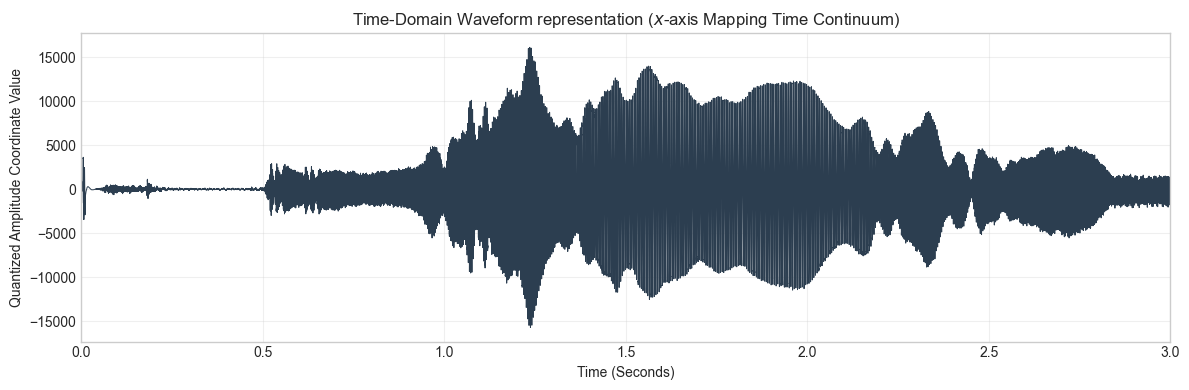

In [17]:
plt.figure(figsize=(12, 4))
# Convert sample indices back into true temporal coordinates for the x-axis
time_axis = np.linspace(0, len(input_data) / input_fs, len(input_data))

plt.plot(time_axis, input_data, color='#2c3e50', linewidth=0.7)
plt.title("Time-Domain Waveform representation ($x$-axis Mapping Time Continuum)", fontsize=12)
plt.xlabel("Time (Seconds)")
plt.ylabel("Quantized Amplitude Coordinate Value")
plt.xlim(0, time_axis[-1])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 4.B: Frequency-Domain Spectrogram Layout
The spectrogram maps the evolution of hidden spectral frequencies over time, computing Short-Time Fourier Transforms (STFT) across discrete windows.

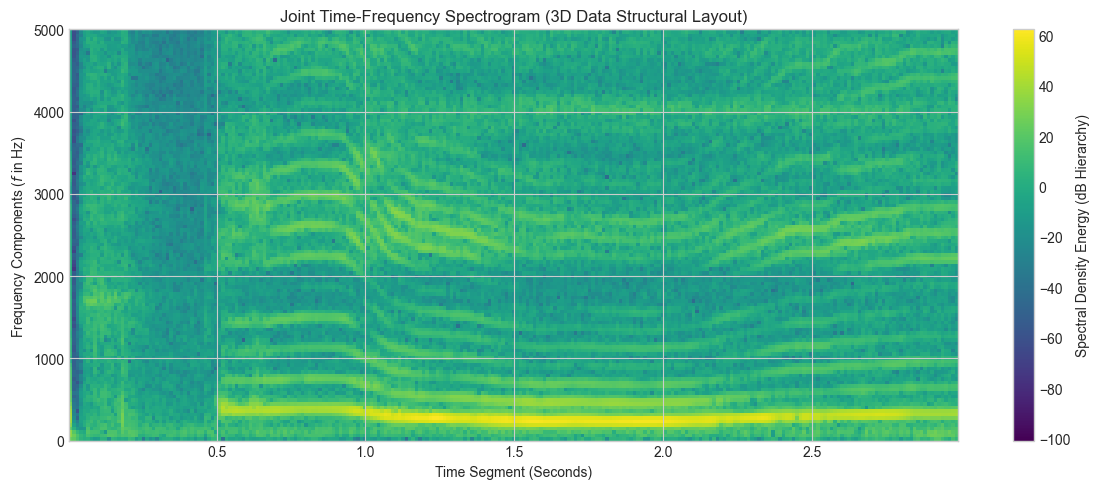

In [18]:
plt.figure(figsize=(12, 5))
# Generate 2D time-frequency distribution plot using a Viridis colormap for density
power_spectrum, frequencies, times, im = plt.specgram(
    input_data, 
    NFFT=1024,      # Window size for each discrete Fourier slice
    Fs=input_fs,    # Target sampling rate parameters [cite: 55]
    noverlap=512,   # 512-sample overlap for temporal smoothing
    cmap='viridis'
)

plt.title("Joint Time-Frequency Spectrogram (3D Data Structural Layout)", fontsize=12)
plt.xlabel("Time Segment (Seconds)")
plt.ylabel("Frequency Components ($f$ in Hz)")
plt.ylim(0, 5000) # Constrain view to the primary human vocal/musical window
cbar = plt.colorbar(im)
cbar.set_label("Spectral Density Energy (dB Hierarchy)")
plt.tight_layout()
plt.show()

### 5. Load an audio file and inspect properties

In [20]:
audio_path = Path("/Users/souvikmandal/Documents/06_Teaching_Mentoring/LS100_comp_etho/2025/media/audio/music_tracks/Eagles_Hotel-California.mp3")  # change to your file
if audio_path.exists():
    y, sr = librosa.load(audio_path, sr=None)
    duration_sec = len(y) / sr
    print("Sample rate:", sr, "Hz  |  Samples:", len(y), "  |  Duration:", round(duration_sec, 2), "s")
else:
    print("Please set audio_path to a real .wav file on your machine.")

Please set audio_path to a real .wav file on your machine.


#### 5.B. Visualize waveform

In [9]:
if 'y' in globals():
    plt.figure()
    librosa.display.waveshow(y, sr=sr)
    plt.title("Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()
else:
    print("Load an audio file first.")

Load an audio file first.


## 6. Tasks:

#### 6.A. Record a short sound using your microphone

In [10]:
# NOTE: This requires local microphone access.
seconds = 3
sr = 16000
print("Recording for", seconds, "seconds...")
rec = sd.rec(int(seconds*sr), samplerate=sr, channels=1)
sd.wait()
rec = rec.flatten()
rec_path = Path("my_recording.wav")
sf.write(str(rec_path), rec, sr)
print("Saved recording to", rec_path)

Recording for 3 seconds...
Saved recording to my_recording.wav


#### 6.B. Compute and visualize a spectrogram of your recording

/Users/souvikmandal/anaconda3/envs/Analysis_Engineering/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


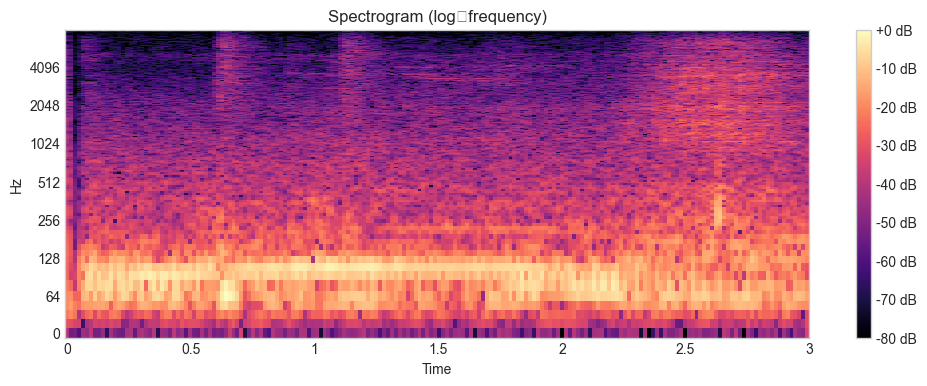

In [11]:
if Path('my_recording.wav').exists():
    y_spec, sr_spec = librosa.load('my_recording.wav', sr=None)
elif 'y' in globals():
    y_spec, sr_spec = y, sr
else:
    y_spec, sr_spec = None, None

if y_spec is not None:
    import numpy as np
    S = np.abs(librosa.stft(y_spec, n_fft=1024, hop_length=256))
    S_db = librosa.amplitude_to_db(S, ref=np.max)
    plt.figure()
    librosa.display.specshow(S_db, sr=sr_spec, hop_length=256, x_axis='time', y_axis='log')
    plt.title('Spectrogram (log‑frequency)')
    plt.colorbar(format='%+2.0f dB')
    plt.show()
else:
    print("Record or load audio first to view a spectrogram.")

#### 7. Practice Tasks

#### 7.A. Trim the first 0.5 seconds of the waveform and re‑plot it.

#### 7.B. Change `n_fft` and `hop_length` values and observe how the spectrogram changes.

#### 7.C. Compute and visualize a **Mel spectrogram**

In [ ]:
# you can use `librosa.feature.melspectrogram`


## 8. Suggested Fun Exercises

These low-cognitive-load, high-impact extensions bridge basic programming directly to acoustic data science:

### Extension A: The "Monster Voice" Illusion (Pitch as a Temporal Property)

* **The Exercise:** Play the Module 2 voice recording, but pass an artificial sample rate argument to the `Audio()` constructor (e.g., `rate = fs_rec // 2`).

 It transforms their voice into a slow, deep "monster" register without changing the numbers inside the data vector. This demonstrates that pitch is strictly an *emergent temporal property* dependent on the playback speed through a DAC, providing a baseline understanding of sample rate conversion algorithms.



### Extension B: The Acoustic Fingerprint of Language (Vowel Formant Mapping)

* **The Exercise:** Record yourself holding two prolonged vowel sounds separately (e.g., "Sustained 'Ooo'" vs. "Sustained 'Eee'") at the *exact same musical pitch*. Have them generate spectrograms for both.

 You will "physically" see that even at identical fundamental frequencies, different mouth shapes create distinct vertical "energy bands" (called formants) on the spectrogram. This forms the architectural foundation for speech processing, vowel classification, and training machine learning models for voice biometric identification.

### Extension C: Simulating Environmental Degradation (Signal-to-Noise Ratio Analysis)

* **The Exercise:** Generate computational white noise using `np.random.normal()` and mathematically append it to their instrument tracks (`clean_signal + noise_factor`), then visualize the resulting visual fuzz on the spectrogram.

* It simulates recording audio in a real-world, noisy field environment. This introduces students to the core data science concept of **SNR (Signal-to-Noise Ratio)** and sets the stage for future research into audio cleaning, filtering, and speech enhancement algorithms.

---